**Import necessary libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, f1_score, classification_report, roc_auc_score, confusion_matrix

**Load Data**

**Train_Test_Split**

In [ ]:
df = pd.read_csv("../data/fraudTrain_prepared.csv")
features = ['amt', 'category', 'gender', 'city_pop', 'hour_of_day', 'day_of_week', 'month', 'lat', 'long', 'merch_lat', 'merch_long']

X= df[features].copy()
y = df['is_fraud'].copy()

# One hot encoding for categorical features
cat_cols = ['category' ,'gender', 'day_of_week', 'month']
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

print(f"Final Features: {X.columns.tolist()}")

Final Features: ['amt', 'city_pop', 'hour_of_day', 'lat', 'long', 'merch_lat', 'merch_long', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'gender_F', 'gender_M', 'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']


**Sampling 30% of training data**

In [ ]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_sample = X_train.sample(frac=0.3, random_state=42)
y_sample = y_train.loc[X_sample.index]

**MODEL TRAINING**

**Sklearn Random Forest Classifier model building**

**RandomizedSearchCV on RandomForestClassifier**

**fit and predict upon best_parameters**

In [4]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=8,      # try only 8 combinations
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_sample, y_sample)
best_rf = random_search.best_estimator_

print("Best Hyperparameters:", random_search.best_params_)

y_probs = best_rf.predict_proba(X_test)[:, 1]

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [5]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

y_pred = (y_probs >= optimal_threshold).astype(int)
print(f"Optimal Threshold: {optimal_threshold:.3f}")

Optimal Threshold: 0.247


In [6]:
print(classification_report(y_test, y_pred, digits= 4))
roc = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC: {roc:.4f}")

              precision    recall  f1-score   support

           0     0.9987    0.9992    0.9990    257834
           1     0.8560    0.7841    0.8185      1501

    accuracy                         0.9980    259335
   macro avg     0.9274    0.8917    0.9087    259335
weighted avg     0.9979    0.9980    0.9979    259335

ROC-AUC: 0.9858


In [7]:
from sklearn.metrics import average_precision_score, confusion_matrix
best_params = random_search.best_params_

final_rf = RandomForestClassifier(
    **best_params,
    bootstrap=True,
    max_samples=0.7,
    random_state=42,
    n_jobs = -1,
    class_weight='balanced'
)

final_rf.fit(X_train, y_train)

y_pred = final_rf.predict(X_test)
y_proba = final_rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, digits = 4))

print(f"\nPR-AUC  : {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0     0.9982    0.9998    0.9990    257834
           1     0.9561    0.6969    0.8062      1501

    accuracy                         0.9981    259335
   macro avg     0.9772    0.8483    0.9026    259335
weighted avg     0.9980    0.9981    0.9979    259335


PR-AUC  : 0.8919
ROC-AUC : 0.9944


In [8]:
print(confusion_matrix(y_test, y_pred))

[[257786     48]
 [   455   1046]]


In [9]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold:", best_threshold)

y_pred_opt = (y_proba >= best_threshold).astype(int)

Best threshold: 0.32666666666666666


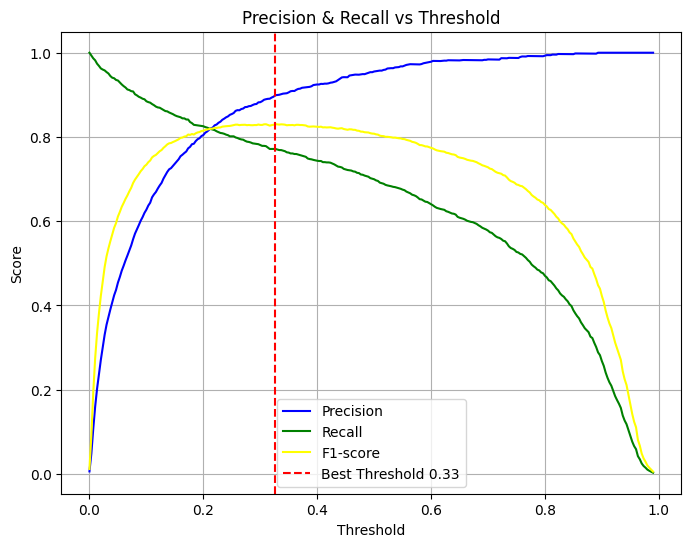

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.plot(thresholds, f1_scores[:-1], label="F1-score", color = 'yellow' )
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
s = pd.DataFrame(y_pred_opt, columns = ['y_pred_opt'])

In [25]:
s.value_counts().sort_values(ascending=False)

y_pred_opt
0             258047
1               1288
Name: count, dtype: int64

In [13]:
feature_importance = pd.Series(
    final_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(20))

amt                        0.541279
hour_of_day                0.172630
category_gas_transport     0.025287
city_pop                   0.022021
category_grocery_pos       0.020314
merch_lat                  0.020062
merch_long                 0.020019
lat                        0.019285
long                       0.019063
category_shopping_net      0.018895
category_home              0.010159
category_food_dining       0.009109
category_misc_net          0.008962
category_shopping_pos      0.007761
category_travel            0.006335
category_entertainment     0.006265
category_misc_pos          0.006244
category_kids_pets         0.006051
category_grocery_net       0.005534
category_health_fitness    0.004953
dtype: float64
